# Unified delivery model comparison

This notebook compares the uploaded SVM, Random Forest, LightGBM, and XGBoost approaches using one consistent setup.

Key decisions baked into the notebook:

- Target: `delivery_days`
- Chronological split: 60% train, 20% validation, 20% test by `order_purchase_timestamp`
- Leakage prevention: `delivery_days_estimated` is **not used as a model feature**. It is used only as a baseline prediction.
- Shared selection metric: asymmetric MSE-style loss where under-predicting delivery time is penalized 5x.
- Final model choice: lowest validation asymmetric MSE. Test results are reported after selection.


## How to run this in Google Colab

1. Open this notebook in Colab.
2. Run the install/import cells.
3. Upload `final_df_20260430.csv` when prompted, or place it at `final_df_20260430.csv`.
4. Run all cells.

The notebook keeps tuning settings modest so it can run on Colab without being painfully slow. Increase `N_ITER` if you want a more exhaustive search.


In [55]:
import os
import io
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.stats import randint, uniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports complete.")
print("pandas:", pd.__version__)
print("LightGBM:", lgb.__version__)
print("XGBoost:", xgb.__version__)


Imports complete.
pandas: 2.3.3
LightGBM: 4.6.0
XGBoost: 3.2.0


In [56]:
# -----------------------------
# Main controls
# -----------------------------

DATA_PATH = "final_df_20260503.csv"

TARGET = "delivery_days"
BASELINE_COL = "delivery_days_estimated"
TIME_COL = "order_purchase_timestamp"

# Use the SVM-style feature set because it was closest to the correct setup.
# The original SVM used a label-encoded customer_state; this notebook uses
# one-hot encoding instead so every model gets the same clean preprocessing.
USE_CUSTOMER_CITY = False  # Set True to include city, but it is slower/high-cardinality.

# Efficient defaults for Colab. Increase these if you want a deeper search.
CV_SPLITS = 3
N_ITER = 12
MAX_TUNE_ROWS = 50_000

# Prediction calibration. Since late predictions are cheaper than missed delays,
# a small positive offset can reduce asymmetric loss. The offset is tuned only on validation.
OFFSET_GRID = np.linspace(-5, 15, 401)

LATE_PENALTY = 5.0
EARLY_PENALTY = 1.0

print("Configuration loaded.")


Configuration loaded.


In [57]:
def load_dataset(path=DATA_PATH):
    if os.path.exists(path):
        print(f"Loading dataset from: {path}")
        return pd.read_csv(path)

    # Colab upload fallback
    try:
        from google.colab import files
        print("Dataset not found at DATA_PATH. Please upload final_df_20260430.csv.")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file uploaded.")
        first_file = next(iter(uploaded))
        print(f"Loading uploaded file: {first_file}")
        return pd.read_csv(io.BytesIO(uploaded[first_file]))
    except ModuleNotFoundError:
        raise FileNotFoundError(
            f"Could not find {path}. Put final_df_20260430.csv in the working directory "
            "or update DATA_PATH."
        )

df = load_dataset()

print("Raw shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Loading dataset from: final_df_20260503.csv
Raw shape: (95138, 43)


,order_id,customer_unique_id,order_status,order_purchase_timestamp,purchase_hour,purchase_dayofweek,delivery_days,delivery_days_estimated,customer_city,customer_state,...,min_delay_product,max_delay_product,p25_delay_product,p75_delay_product,avg_cancel_product,mediancancel_product,min_cancel_product,max_cancel_product,p25_cancel_product,p75_cancel_product
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,8,2,7.614421,15.625671,campos dos goytacazes,RJ,...,0.032895,0.032895,0.032895,0.032895,0.0,0.0,0.0,0.0,0.0,0.0
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,10,2,16.216181,18.546458,santa fe do sul,SP,...,0.025424,0.025424,0.025424,0.025424,0.0,0.0,0.0,0.0,0.0,0.0
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,14,6,7.948437,21.393391,para de minas,MG,...,0.070655,0.070655,0.070655,0.070655,0.0,0.0,0.0,0.0,0.0,0.0
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,10,2,6.147269,11.582928,atibaia,SP,...,0.074413,0.074413,0.074413,0.074413,0.0,0.0,0.0,0.0,0.0,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,13,5,25.114352,40.418160,varzea paulista,SP,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0



Columns:
['order_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'purchase_hour', 'purchase_dayofweek', 'delivery_days', 'delivery_days_estimated', 'customer_city', 'customer_state', 'max_distance', 'num_items', 'order_price', 'order_weight', 'order_volume', 'avg_photos_per_product', 'avg_product_description_length', 'n_states', 'n_cities', 'avg_delay_sellers', 'median_delay_sellers', 'min_delay_sellers', 'max_delay_sellers', 'p25_delay_sellers', 'p75_delay_sellers', 'avg_cancel_sellers', 'mediancancel_sellers', 'min_cancel_sellers', 'max_cancel_sellers', 'p25_cancel_sellers', 'p75_cancel_sellers', 'avg_delay_product', 'median_delay_product', 'min_delay_product', 'max_delay_product', 'p25_delay_product', 'p75_delay_product', 'avg_cancel_product', 'mediancancel_product', 'min_cancel_product', 'max_cancel_product', 'p25_cancel_product', 'p75_cancel_product']


In [59]:
required_cols = [TARGET, TIME_COL]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df.copy()
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

before = len(df)
df = df.dropna(subset=[TARGET, TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after:,} rows with missing {TARGET} or {TIME_COL}.")
print("Clean shape:", df.shape)
print("Date range:", df[TIME_COL].min(), "to", df[TIME_COL].max())

# SVM-style numeric feature list.
candidate_numeric_features = [
    # Order timing
    "purchase_hour",
    "purchase_dayofweek",
    # "approval_delay_hours",

    # Geography
    "max_distance",

    # Order characteristics
    "num_items",
    "order_price",
    "order_weight",
    "order_volume",
    "avg_photos_per_product",
    "avg_product_description_length",
    "n_states",
    "n_cities",

    # Seller delay/cancel history
    "avg_delay_sellers",
    "median_delay_sellers",
    "p25_delay_sellers",
    "p75_delay_sellers",
    "avg_cancel_sellers",

    # Product delay/cancel history
    "avg_delay_product",
    "median_delay_product",
    "p25_delay_product",
    "p75_delay_product",
    "avg_cancel_product",
]

candidate_categorical_features = ["customer_state"]
if USE_CUSTOMER_CITY:
    candidate_categorical_features.append("customer_city")

numeric_features = [c for c in candidate_numeric_features if c in df.columns]
categorical_features = [c for c in candidate_categorical_features if c in df.columns]

missing_candidate_features = sorted(
    set(candidate_numeric_features + candidate_categorical_features) - set(numeric_features + categorical_features)
)
if missing_candidate_features:
    print("These expected features were not found and will be skipped:")
    print(missing_candidate_features)

FEATURES = numeric_features + categorical_features

# Hard leakage guard.
never_use_as_features = {
    "order_id",
    "customer_unique_id",
    "order_status",
    TIME_COL,
    TARGET,
    BASELINE_COL,
    "estimated_delivery_time",
    "order_estimated_delivery_date",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "order_approved_at",
}
leaky_present = [c for c in FEATURES if c in never_use_as_features]
if leaky_present:
    raise ValueError(f"Leakage columns slipped into FEATURES: {leaky_present}")

if BASELINE_COL in FEATURES:
    raise ValueError(f"{BASELINE_COL} must not be used as a model feature.")

print(f"Using {len(numeric_features)} numeric features and {len(categorical_features)} categorical features.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"Baseline column available: {BASELINE_COL in df.columns}")


Dropped 0 rows with missing delivery_days or order_purchase_timestamp.
Clean shape: (95138, 43)
Date range: 2016-09-15 12:16:38 to 2018-08-29 15:00:37
Using 21 numeric features and 1 categorical features.
Numeric features: ['purchase_hour', 'purchase_dayofweek', 'max_distance', 'num_items', 'order_price', 'order_weight', 'order_volume', 'avg_photos_per_product', 'avg_product_description_length', 'n_states', 'n_cities', 'avg_delay_sellers', 'median_delay_sellers', 'p25_delay_sellers', 'p75_delay_sellers', 'avg_cancel_sellers', 'avg_delay_product', 'median_delay_product', 'p25_delay_product', 'p75_delay_product', 'avg_cancel_product']
Categorical features: ['customer_state']
Baseline column available: True


In [60]:
n = len(df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_val = val_df[FEATURES].copy()
y_val = val_df[TARGET].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

print("Split sizes:")
print(f"  train: {len(train_df):,} rows | {train_df[TIME_COL].min()} to {train_df[TIME_COL].max()}")
print(f"  val:   {len(val_df):,} rows | {val_df[TIME_COL].min()} to {val_df[TIME_COL].max()}")
print(f"  test:  {len(test_df):,} rows | {test_df[TIME_COL].min()} to {test_df[TIME_COL].max()}")

# Use the most recent part of train for hyperparameter search to keep runtime reasonable.
if len(X_train) > MAX_TUNE_ROWS:
    X_tune = X_train.iloc[-MAX_TUNE_ROWS:].copy()
    y_tune = y_train.iloc[-MAX_TUNE_ROWS:].copy()
else:
    X_tune = X_train.copy()
    y_tune = y_train.copy()

print(f"Rows used for hyperparameter tuning: {len(X_tune):,}")


Split sizes:
  train: 57,082 rows | 2016-09-15 12:16:38 to 2018-03-04 13:46:32
  val:   19,028 rows | 2018-03-04 13:48:11 to 2018-05-28 13:31:20
  test:  19,028 rows | 2018-05-28 13:37:22 to 2018-08-29 15:00:37
Rows used for hyperparameter tuning: 50,000


In [61]:
def asymmetric_mse(y_true, y_pred, late_penalty=LATE_PENALTY, early_penalty=EARLY_PENALTY):
    """MSE-style asymmetric loss.

    error = actual - predicted

    Positive error means the model predicted too early / too low.
    That misses a late delivery, so it gets the higher late_penalty.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    error = y_true - y_pred
    weights = np.where(error > 0, late_penalty, early_penalty)
    return float(np.mean(weights * error ** 2))


# def asymmetric_mse(y_true, y_pred, late_penalty=5.0, early_penalty=1.0, cap=30):
#     y_true = np.asarray(y_true, dtype=float)
#     y_pred = np.asarray(y_pred, dtype=float)

#     error = y_true - y_pred

#     late_error = np.clip(error, 0, cap)
#     early_error = np.clip(-error, 0, cap)

#     return np.mean(
#         late_penalty * late_error**2 +
#         early_penalty * early_error**2
#     )

delivery_scorer = make_scorer(
    asymmetric_mse,
    greater_is_better=False,
    late_penalty=LATE_PENALTY,
    early_penalty=EARLY_PENALTY,
)


def find_best_offset(y_true, raw_pred, grid=OFFSET_GRID):
    """Find a scalar offset that minimizes asymmetric MSE on validation data."""
    losses = []
    raw_pred = np.asarray(raw_pred, dtype=float)
    for offset in grid:
        pred = np.maximum(raw_pred + offset, 0)  # delivery days cannot be negative
        losses.append(asymmetric_mse(y_true, pred))
    best_idx = int(np.argmin(losses))
    return float(grid[best_idx]), float(losses[best_idx])


def predict_with_offset(model, X, offset):
    return np.maximum(model.predict(X) + offset, 0)


def metrics_dict(y_true, y_pred):
    error = np.asarray(y_true) - np.asarray(y_pred)
    return {
        "asymmetric_mse": asymmetric_mse(y_true, y_pred),
        "mse": mean_squared_error(y_true, y_pred),
        "rmse_days": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae_days": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "mean_error_actual_minus_pred": float(np.mean(error)),
        "pct_underpredicted": float(np.mean(error > 0)),
    }


# Tiny sanity check: missing by 2 days should cost 5x the same-size conservative error.
print("Loss for actual=10, predicted=8:", asymmetric_mse([10], [8]))
print("Loss for actual=10, predicted=12:", asymmetric_mse([10], [12]))


Loss for actual=10, predicted=8: 20.0
Loss for actual=10, predicted=12: 4.0


In [62]:
def make_one_hot_encoder():
    # sparse_output was introduced in newer sklearn versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessor(scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    transformers = []
    if numeric_features:
        transformers.append(("num", Pipeline(numeric_steps), numeric_features))

    if categorical_features:
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ])
        transformers.append(("cat", categorical_pipeline, categorical_features))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.3,
    )


preprocessor_tree = build_preprocessor(scale_numeric=False)
preprocessor_scaled = build_preprocessor(scale_numeric=True)

print("Preprocessors ready.")


Preprocessors ready.


In [63]:
model_configs = []

model_configs.append({
    "name": "LinearSVR",
    "estimator": Pipeline([
        ("preprocessor", clone(preprocessor_scaled)),
        ("model", LinearSVR(random_state=RANDOM_STATE, max_iter=30_000)),
    ]),
    "search": "grid",
    "params": {
        "model__C": [0.1, 1.0, 10.0],
        "model__epsilon": [0.0, 0.1, 0.5],
    },
})

model_configs.append({
    "name": "RandomForest",
    "estimator": Pipeline([
        ("preprocessor", clone(preprocessor_tree)),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            bootstrap=True,
        )),
    ]),
    "search": "random",
    "params": {
        "model__n_estimators": randint(100, 301),
        "model__max_depth": [8, 12, 18, None],
        "model__min_samples_leaf": randint(1, 9),
        "model__min_samples_split": randint(2, 12),
        "model__max_features": ["sqrt", 0.7, 1.0],
    },
})

model_configs.append({
    "name": "LightGBM",
    "estimator": Pipeline([
        ("preprocessor", clone(preprocessor_tree)),
        ("model", lgb.LGBMRegressor(
            objective="regression",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )),
    ]),
    "search": "random",
    "params": {
        "model__n_estimators": randint(150, 701),
        "model__learning_rate": uniform(0.02, 0.12),
        "model__num_leaves": randint(20, 80),
        "model__max_depth": [-1, 4, 6, 8, 10],
        "model__min_child_samples": randint(10, 80),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__reg_alpha": uniform(0.0, 0.5),
        "model__reg_lambda": uniform(0.0, 0.5),
    },
})

model_configs.append({
    "name": "XGBoost",
    "estimator": Pipeline([
        ("preprocessor", clone(preprocessor_tree)),
        ("model", xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )),
    ]),
    "search": "random",
    "params": {
        "model__n_estimators": randint(150, 701),
        "model__max_depth": randint(3, 9),
        "model__learning_rate": uniform(0.02, 0.12),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_weight": randint(1, 10),
        "model__reg_alpha": uniform(0.0, 0.5),
        "model__reg_lambda": uniform(0.0, 1.0),
    },
})

print("Models to compare:")
for cfg in model_configs:
    print(" -", cfg["name"])


Models to compare:
 - LinearSVR
 - RandomForest
 - LightGBM
 - XGBoost


In [64]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

fitted_models = {}
search_summaries = []
results = []
predictions = {}

# Baseline from Olist estimated delivery days. It is not used as a model input.
if BASELINE_COL in df.columns:
    for split_name, split_df, y_split in [
        ("validation", val_df, y_val),
        ("test", test_df, y_test),
    ]:
        raw_baseline_pred = pd.to_numeric(split_df[BASELINE_COL], errors="coerce").to_numpy()
        valid_mask = ~np.isnan(raw_baseline_pred)
        if valid_mask.sum() == 0:
            print(f"No valid baseline predictions for {split_name}.")
            continue

    baseline_val_raw = pd.to_numeric(val_df[BASELINE_COL], errors="coerce").to_numpy()
    baseline_test_raw = pd.to_numeric(test_df[BASELINE_COL], errors="coerce").to_numpy()

    baseline_offset, baseline_val_loss = find_best_offset(y_val, baseline_val_raw)
    baseline_val_pred = np.maximum(baseline_val_raw, 0)
    baseline_val_pred_cal = np.maximum(baseline_val_raw + baseline_offset, 0)
    baseline_test_pred = np.maximum(baseline_test_raw, 0)
    baseline_test_pred_cal = np.maximum(baseline_test_raw + baseline_offset, 0)

    for label, offset, vpred, tpred in [
        ("Baseline estimate", 0.0, baseline_val_pred, baseline_test_pred),
        ("Baseline estimate + offset", baseline_offset, baseline_val_pred_cal, baseline_test_pred_cal),
    ]:
        val_metrics = metrics_dict(y_val, vpred)
        test_metrics = metrics_dict(y_test, tpred)
        results.append({
            "kind": "baseline",
            "model": label,
            "cv_asymmetric_mse": np.nan,
            "offset_days": offset,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            **{f"test_{k}": v for k, v in test_metrics.items()},
        })
else:
    print(f"{BASELINE_COL} was not found, so baseline comparison is skipped.")


for cfg in model_configs:
    name = cfg["name"]
    print("\n" + "=" * 80)
    print(f"Training and tuning: {name}")
    print("=" * 80)

    estimator = clone(cfg["estimator"])

    if cfg["search"] == "grid":
        search = GridSearchCV(
            estimator=estimator,
            param_grid=cfg["params"],
            scoring=delivery_scorer,
            cv=tscv,
            n_jobs=-1,
            verbose=1,
            refit=True,
        )
    else:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=cfg["params"],
            n_iter=N_ITER,
            scoring=delivery_scorer,
            cv=tscv,
            n_jobs=-1,
            verbose=1,
            random_state=RANDOM_STATE,
            refit=True,
        )

    search.fit(X_tune, y_tune)

    best_params = search.best_params_
    best_cv_loss = -float(search.best_score_)

    print(f"Best CV asymmetric MSE: {best_cv_loss:.4f}")
    print("Best params:", best_params)

    # Refit the best configuration on the full training set.
    final_model = clone(cfg["estimator"]).set_params(**best_params)
    final_model.fit(X_train, y_train)

    # Validation offset calibration.
    val_raw = final_model.predict(X_val)
    offset, val_loss_after_offset = find_best_offset(y_val, val_raw)
    val_pred = predict_with_offset(final_model, X_val, offset)
    test_pred = predict_with_offset(final_model, X_test, offset)

    val_metrics = metrics_dict(y_val, val_pred)
    test_metrics = metrics_dict(y_test, test_pred)

    fitted_models[name] = final_model
    predictions[name] = {
        "offset": offset,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }
    search_summaries.append({
        "model": name,
        "best_cv_asymmetric_mse": best_cv_loss,
        "best_params": best_params,
    })
    results.append({
        "kind": "model",
        "model": name,
        "cv_asymmetric_mse": best_cv_loss,
        "offset_days": offset,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })

    print(f"Validation asymmetric MSE after offset: {val_metrics['asymmetric_mse']:.4f}")
    print(f"Test asymmetric MSE after offset:       {test_metrics['asymmetric_mse']:.4f}")
    print(f"Calibrated prediction offset:           {offset:.3f} days")



Training and tuning: LinearSVR
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best CV asymmetric MSE: 459.4771
Best params: {'model__C': 10.0, 'model__epsilon': 0.0}
Validation asymmetric MSE after offset: 209.8258
Test asymmetric MSE after offset:       145.5006
Calibrated prediction offset:           6.150 days

Training and tuning: RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV asymmetric MSE: 381.3080
Best params: {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 6, 'model__min_samples_split': 3, 'model__n_estimators': 291}
Validation asymmetric MSE after offset: 193.8683
Test asymmetric MSE after offset:       142.3091
Calibrated prediction offset:           3.200 days

Training and tuning: LightGBM
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV asymmetric MSE: 384.3604
Best params: {'model__colsample_bytree': np.float64(0.8773893363123181), 'model__learning_rate': np.float64(0.0

In [65]:
results_df = pd.DataFrame(results)

ordered_cols = [
    "kind", "model", "cv_asymmetric_mse", "offset_days",
    "val_asymmetric_mse", "val_rmse_days", "val_mae_days", "val_r2",
    "test_asymmetric_mse", "test_rmse_days", "test_mae_days", "test_r2",
    "val_mean_error_actual_minus_pred", "test_mean_error_actual_minus_pred",
    "val_pct_underpredicted", "test_pct_underpredicted",
]
ordered_cols = [c for c in ordered_cols if c in results_df.columns]
results_df = results_df[ordered_cols].sort_values("val_asymmetric_mse").reset_index(drop=True)

print("Model comparison sorted by validation asymmetric MSE.")
display(results_df.style.format({
    "cv_asymmetric_mse": "{:.4f}",
    "offset_days": "{:.3f}",
    "val_asymmetric_mse": "{:.4f}",
    "val_rmse_days": "{:.4f}",
    "val_mae_days": "{:.4f}",
    "val_r2": "{:.4f}",
    "test_asymmetric_mse": "{:.4f}",
    "test_rmse_days": "{:.4f}",
    "test_mae_days": "{:.4f}",
    "test_r2": "{:.4f}",
    "val_mean_error_actual_minus_pred": "{:.4f}",
    "test_mean_error_actual_minus_pred": "{:.4f}",
    "val_pct_underpredicted": "{:.2%}",
    "test_pct_underpredicted": "{:.2%}",
}))

model_results = results_df[results_df["kind"] == "model"].copy()
if model_results.empty:
    raise RuntimeError("No trainable model results were produced.")

best_model_name = model_results.iloc[0]["model"]
best_offset = float(model_results.iloc[0]["offset_days"])
best_model = fitted_models[best_model_name]

print(f"Best trainable model by validation asymmetric MSE: {best_model_name}")
print(f"Offset to apply to predictions: {best_offset:.3f} days")

baseline_rows = results_df[results_df["kind"] == "baseline"]
if not baseline_rows.empty:
    best_baseline = baseline_rows.iloc[0]
    print("\nBest baseline row:")
    display(best_baseline.to_frame().T)
    if float(best_baseline["val_asymmetric_mse"]) < float(model_results.iloc[0]["val_asymmetric_mse"]):
        print("Note: the baseline beats the trainable models on validation asymmetric MSE.")
        print("Use this as a reality check before replacing the existing estimate.")


Model comparison sorted by validation asymmetric MSE.


,kind,model,cv_asymmetric_mse,offset_days,val_asymmetric_mse,val_rmse_days,val_mae_days,val_r2,test_asymmetric_mse,test_rmse_days,test_mae_days,test_r2,val_mean_error_actual_minus_pred,test_mean_error_actual_minus_pred,val_pct_underpredicted,test_pct_underpredicted
0,model,LightGBM,384.3604,3.800,191.4960,9.7042,8.0035,-0.0245,142.8917,10.8919,9.6753,-2.4296,-5.3303,-9.0619,17.34%,4.57%
1,model,XGBoost,383.8341,3.750,192.0335,9.7201,8.0064,-0.0279,142.3718,10.8835,9.6417,-2.4243,-5.3371,-9.0435,17.12%,4.55%
2,model,RandomForest,381.3080,3.200,193.8683,9.7725,8.0460,-0.0390,142.3091,10.9156,9.7211,-2.4445,-5.3627,-9.1420,17.19%,4.50%
3,model,LinearSVR,459.4771,6.150,209.8258,10.0299,8.5172,-0.0945,145.5006,11.0993,10.3308,-2.5615,-5.6671,-9.7998,17.04%,3.55%
4,baseline,Baseline estimate + offset,nan,-3.600,239.5928,11.4184,9.0460,-0.4185,202.8563,13.1441,10.1872,-3.9945,-6.0420,-8.9152,18.87%,16.02%
5,baseline,Baseline estimate,nan,0.000,261.1154,13.6690,11.5736,-1.0328,268.0899,15.8090,13.0372,-6.2251,-9.6420,-12.5010,11.29%,5.34%


Best trainable model by validation asymmetric MSE: LightGBM
Offset to apply to predictions: 3.800 days

Best baseline row:


,kind,model,cv_asymmetric_mse,offset_days,val_asymmetric_mse,val_rmse_days,val_mae_days,val_r2,test_asymmetric_mse,test_rmse_days,test_mae_days,test_r2,val_mean_error_actual_minus_pred,test_mean_error_actual_minus_pred,val_pct_underpredicted,test_pct_underpredicted
4,baseline,Baseline estimate + offset,NaN,-3.6,239.592806,11.41836,9.046028,-0.418469,202.856278,13.144056,10.187237,-3.994528,-6.042014,-8.915206,0.188669,0.160185


Diagnostics for best model: LightGBM
Mean actual - predicted error: -9.0619 days
Median actual - predicted error: -9.1135 days
Underpredicted share: 4.57%


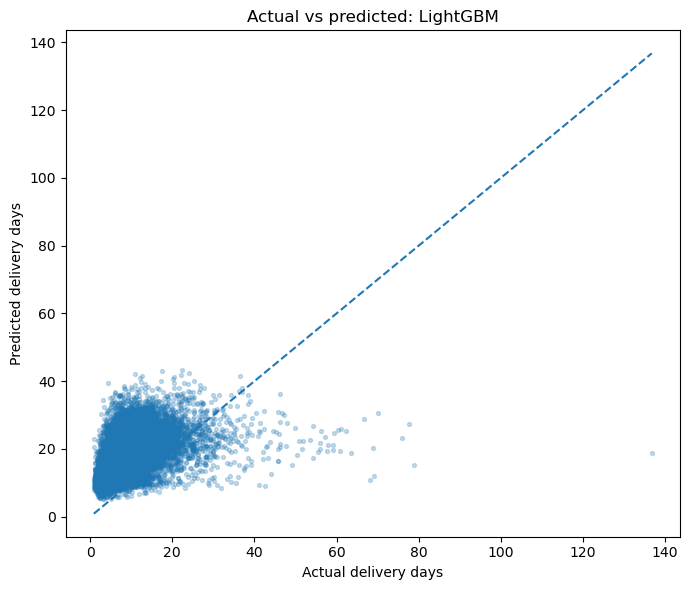

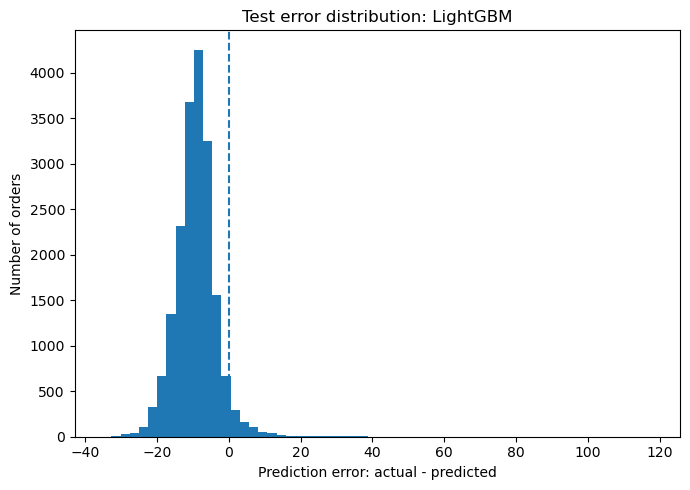

In [66]:
best_test_pred = predictions[best_model_name]["test_pred"]
test_error = y_test.to_numpy() - best_test_pred

print(f"Diagnostics for best model: {best_model_name}")
print(f"Mean actual - predicted error: {np.mean(test_error):.4f} days")
print(f"Median actual - predicted error: {np.median(test_error):.4f} days")
print(f"Underpredicted share: {np.mean(test_error > 0):.2%}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_test_pred, alpha=0.25, s=8)
lims = [
    min(float(np.min(y_test)), float(np.min(best_test_pred))),
    max(float(np.max(y_test)), float(np.max(best_test_pred))),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title(f"Actual vs predicted: {best_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(test_error, bins=60)
plt.axvline(0, linestyle="--")
plt.xlabel("Prediction error: actual - predicted")
plt.ylabel("Number of orders")
plt.title(f"Test error distribution: {best_model_name}")
plt.tight_layout()
plt.show()


,feature,importance
2,max_distance,1625
6,order_volume,1322
8,avg_product_description_length,1301
4,order_price,1281
5,order_weight,1098
16,avg_delay_product,927
11,avg_delay_sellers,597
0,purchase_hour,499
18,p25_delay_product,416
1,purchase_dayofweek,413


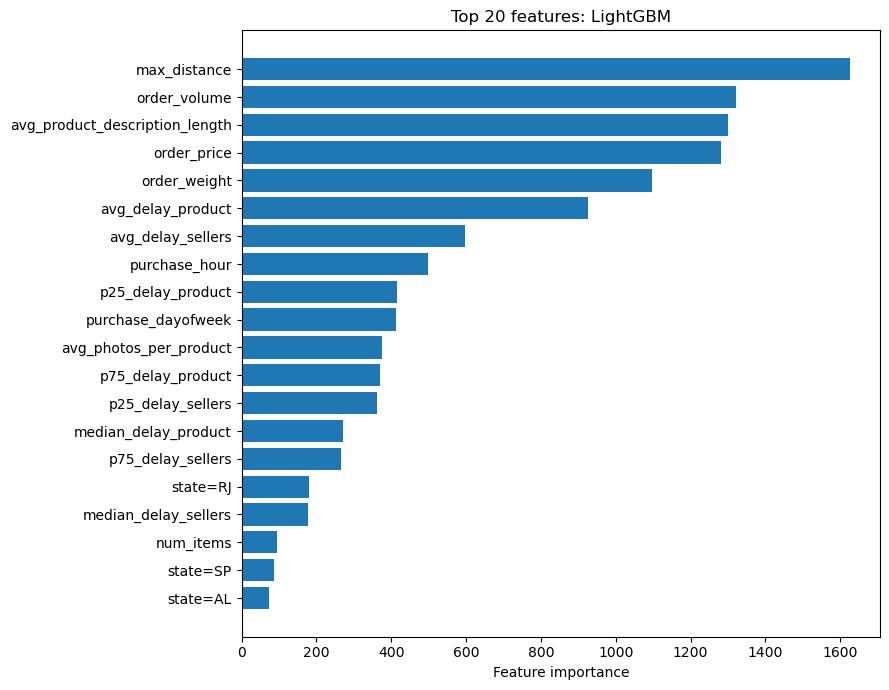

In [67]:
def clean_feature_name(name):
    return (
        name.replace("num__", "")
            .replace("cat__", "")
            .replace("customer_state_", "state=")
            .replace("customer_city_", "city=")
    )


def show_feature_importance(pipeline, top_n=20):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    try:
        feature_names = preprocessor.get_feature_names_out()
        feature_names = [clean_feature_name(str(x)) for x in feature_names]
    except Exception as exc:
        print("Could not recover transformed feature names:", exc)
        return

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
        label = "Feature importance"
    elif hasattr(model, "coef_"):
        importance = np.abs(np.ravel(model.coef_))
        label = "Absolute coefficient"
    else:
        print(f"{type(model).__name__} does not expose feature_importances_ or coef_.")
        return

    if len(importance) != len(feature_names):
        print("Importance length did not match transformed feature count.")
        print("Importance length:", len(importance))
        print("Feature count:", len(feature_names))
        return

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    display(importance_df)

    plt.figure(figsize=(9, 7))
    plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
    plt.xlabel(label)
    plt.title(f"Top {top_n} features: {best_model_name}")
    plt.tight_layout()
    plt.show()


show_feature_importance(best_model, top_n=20)


In [68]:
artifact = {
    "model": best_model,
    "offset_days": best_offset,
    "features": FEATURES,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target": TARGET,
    "baseline_col": BASELINE_COL,
    "loss": {
        "name": "asymmetric_mse",
        "late_penalty": LATE_PENALTY,
        "early_penalty": EARLY_PENALTY,
        "formula": "mean(where(actual - predicted > 0, late_penalty, early_penalty) * (actual - predicted)^2)",
    },
    "best_model_name": best_model_name,
    "results": results_df,
}

joblib.dump(artifact, "best_delivery_model.joblib")
results_df.to_csv("model_comparison_results.csv", index=False)

predictions_out = test_df[["order_id", TIME_COL, TARGET]].copy() if "order_id" in test_df.columns else test_df[[TIME_COL, TARGET]].copy()
if BASELINE_COL in test_df.columns:
    predictions_out[BASELINE_COL] = test_df[BASELINE_COL].values
predictions_out["predicted_delivery_days"] = best_test_pred
predictions_out["prediction_error_actual_minus_pred"] = y_test.to_numpy() - best_test_pred
predictions_out.to_csv("best_model_test_predictions.csv", index=False)

print("Saved:")
print(" - best_delivery_model.joblib")
print(" - model_comparison_results.csv")
print(" - best_model_test_predictions.csv")

# Optional Colab downloads:
# from google.colab import files
# files.download("best_delivery_model.joblib")
# files.download("model_comparison_results.csv")
# files.download("best_model_test_predictions.csv")


Saved:
 - best_delivery_model.joblib
 - model_comparison_results.csv
 - best_model_test_predictions.csv


In [77]:
import joblib

artifact = joblib.load("best_delivery_model.joblib")
model = artifact["model"]
offset = artifact["offset_days"]

In [76]:
df = pd.read_csv("final_df_20260503.csv")

In [71]:
late_orders = df[df['delivery_days_estimated'] < df['delivery_days']].head()

In [79]:
model_estimates_on_late = model.predict(df[FEATURES])

In [80]:
df['model_predictions'] = model_estimates_on_late + offset

In [ ]:
df[['order_id', 'num_items', 'delivery_days', 'delivery_days_estimated', 'model_predictions']].sort_values('num_items', ascending=False)

,order_id,num_items,delivery_days,delivery_days_estimated,model_predictions
50868,895ab968e7bb0d5659d16cd74cd1650c,63,5.680405,21.148252,11.623425
94729,fedcd9f7ccdc8cba3a18defedd1a5547,38,25.318808,29.377257,28.635683
76208,ccf804e764ed5650cd8759557269dc13,26,15.166389,20.496412,16.364328
73735,c6492b842ac190db807c15aff21a7dd6,24,11.578692,20.014282,16.633462
26136,465c2e1bee4561cb39e0db8c5993aafc,24,14.149213,22.309410,15.897395
...,...,...,...,...,...
34006,5bcf5ca118d9e81440bf98e26c943255,1,9.086273,21.207373,16.874633
34005,5bcde4ca8f0878aab60dc18cc310fa4d,1,5.234410,15.504502,17.858497
34003,5bcc0d98a5287486bbe51150e6ed90f9,1,8.038275,16.182292,12.199655
34002,5bca8968c7bbe677fbb54e8d8b3d331e,1,14.012697,26.034387,16.727524


In [75]:
model_under = (df["model_predictions"] < df["delivery_days"]).sum()
olist_under = (df["delivery_days_estimated"] < df["delivery_days"]).sum()

print("Model underpredicted:", model_under)
print("Olist underpredicted:", olist_under)
print("Model underprediction rate:", model_under / len(df))
print("Olist underprediction rate:", olist_under / len(df))

Model underpredicted: 14977
Olist underpredicted: 7707
Model underprediction rate: 0.15742395257415542
Olist underprediction rate: 0.08100864008072484


In [83]:
df[(df["model_predictions"] >= df["delivery_days"]) & (df["delivery_days_estimated"] < df["delivery_days"])][['order_id', 'num_items', 'delivery_days', 'delivery_days_estimated', 'model_predictions']].sort_values('num_items', ascending=False)

,order_id,num_items,delivery_days,delivery_days_estimated,model_predictions
17981,30b66faf9517facb67ba9b710f0b9628,7,13.669479,13.097917,13.705313
63194,aa9113495d5498b01ea4a235c64f2849,7,17.946921,17.209884,18.673160
11905,201183426051cfc62c56f2414b2480e3,6,9.895972,4.258137,12.282702
7225,135b582ac1ec8138d4f9f0ef27a7ba36,6,20.082940,17.151400,24.336585
9837,1a6b9a764637acbc39e1624a2211f548,6,16.479225,13.612025,17.564770
...,...,...,...,...,...
33944,5b9e9502eca103a28ea22a94c65e3950,1,21.387442,13.598727,24.832920
34104,5c11e238c0563cab5491de26eb68f99a,1,20.149248,18.219433,21.436643
34145,5c2c3051e99aa85bb1f2260f51e59f49,1,11.582269,8.110162,17.024064
34184,5c4b6f896e003ca0b2a00ac3d1124822,1,5.471759,4.985683,10.436657


In [84]:
wdf = pd.read_csv("working_data_20260503.csv")

In [101]:
wdf[wdf["order_id"] == "6c8c2eaa3f73e88dd6dec1b8e00648e3"]['product_category_name_english']

20425    health_beauty
20426    health_beauty
20427    health_beauty
20428    health_beauty
Name: product_category_name_english, dtype: object